# Michigan — SUD Critical Incidents & Sentinel Events EDA
**Source:** Michigan DHHS — FOIA Request, SUD/Sentinel Event data Oct 2022–Mar 2026
**Dataset:** Critical incident reports for Substance Use Disorder programs
**Rows:** ~11,980 | **Fields:** Event type, sub-type, SUD sentinel flag, reviewer dates

This notebook explores Michigan's Substance Use Disorder critical incident reporting,
focusing on event patterns, sentinel events, and review timelines.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
mi = pd.read_csv("../../data/source/Michigan/MI - Critical_Incident._SUD_Sentinel_Event_FOIA_Request.1-1-23_to_1-1-25.xlsx - FOIA Request 10.1.22-3.18.26.csv")

date_cols = ['Date of Incident', 'Date IR Reviewed by Clinician', 'Date IR Reviewed by SERC Coordinator']
for col in date_cols:
    mi[col] = pd.to_datetime(mi[col], errors='coerce')

mi['Is SUD Sentinel'] = mi['Is this a SUD Sentinel Event?'].map({1.0: 'Yes', 0.0: 'No'})
mi['year']  = mi['Date of Incident'].dt.year
mi['month'] = mi['Date of Incident'].dt.to_period('M')

print(f"Rows: {len(mi):,}  |  Columns: {list(mi.columns)}")
mi.head(3)


Rows: 11,980  |  Columns: ['Date of Incident', 'Event Type', 'Event Sub-Type', 'Event Sub-Type Qualifier', 'Date IR Reviewed by Clinician', 'Date IR Reviewed by SERC Coordinator', 'Is this a SUD Sentinel Event?', 'Is SUD Sentinel', 'year', 'month']


,Date of Incident,Event Type,Event Sub-Type,Event Sub-Type Qualifier,Date IR Reviewed by Clinician,Date IR Reviewed by SERC Coordinator,Is this a SUD Sentinel Event?,Is SUD Sentinel,year,month
0,2023-01-01,Emergency Medical Treatment,Injury,Injury was not during physical management,NaT,NaT,0.0,No,2023.0,2023-01
1,2023-01-01,Non-Suicide Death,Natural Causes,Neurological disorders,2023-01-13,NaT,0.0,No,2023.0,2023-01
2,2023-01-01,Non-Suicide Death,Natural Causes,Unknown,NaT,NaT,0.0,No,2023.0,2023-01


In [3]:
# ── Overview ────────────────────────────────────────────────────────────────
print("=== Missing values ===")
print(mi.isnull().sum())
print()
print(f"Date range: {mi['Date of Incident'].min().date()} → {mi['Date of Incident'].max().date()}")
print(f"SUD Sentinel Events: {(mi['Is this a SUD Sentinel Event?'] == 1).sum()} "
      f"({(mi['Is this a SUD Sentinel Event?']==1).mean()*100:.1f}%)")


=== Missing values ===
Date of Incident                         4921
Event Type                               4921
Event Sub-Type                           5764
Event Sub-Type Qualifier                 6445
Date IR Reviewed by Clinician            9619
Date IR Reviewed by SERC Coordinator    10310
Is this a SUD Sentinel Event?            4921
Is SUD Sentinel                          4921
year                                     4921
month                                    4921
dtype: int64

Date range: 2023-01-01 → 2024-12-31
SUD Sentinel Events: 26 (0.2%)


## 1 · Event Type Distribution

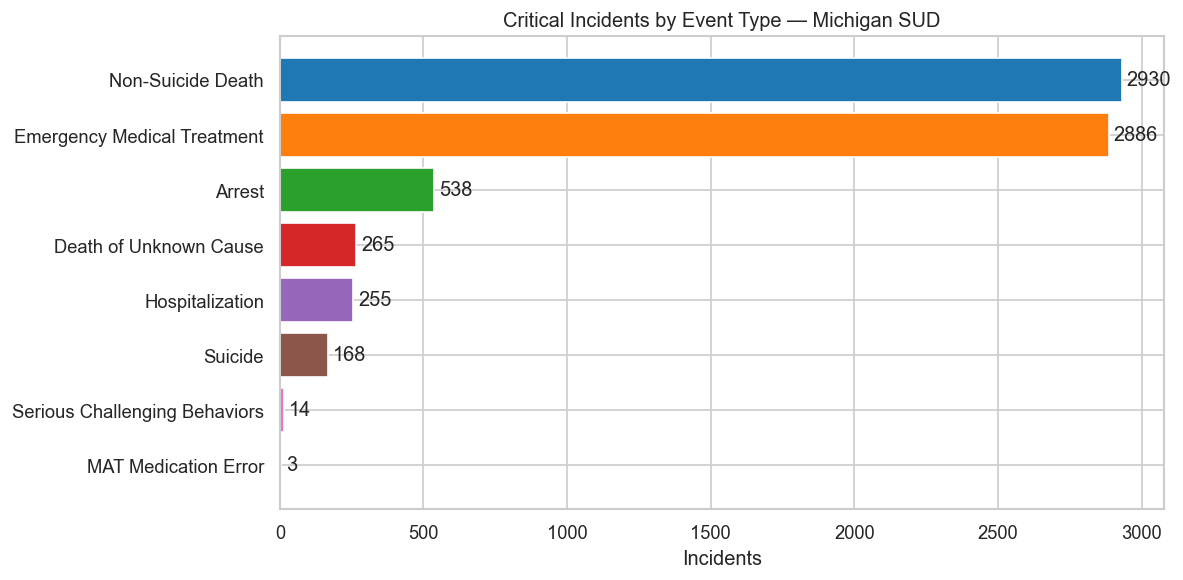

                               count   pct
Event Type                                
Non-Suicide Death               2930  41.5
Emergency Medical Treatment     2886  40.9
Arrest                           538   7.6
Death of Unknown Cause           265   3.8
Hospitalization                  255   3.6
Suicide                          168   2.4
Serious Challenging Behaviors     14   0.2
MAT Medication Error               3   0.0


In [4]:
evt = mi['Event Type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(evt.index, evt.values, color=sns.color_palette('tab10', len(evt)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Incidents')
ax.set_title('Critical Incidents by Event Type — Michigan SUD')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

total = evt.sum()
print(evt.to_frame('count').assign(pct=lambda d: (d['count']/total*100).round(1)))


## 2 · Monthly Trend

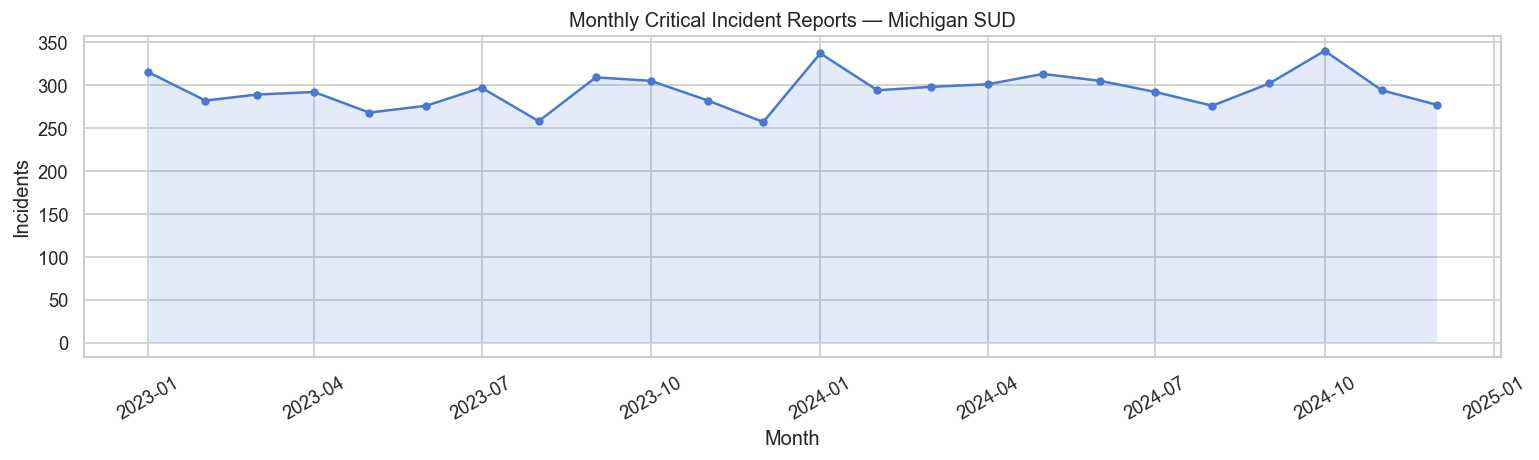

In [5]:
monthly = mi.groupby('month').size().reset_index(name='count')
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['month_dt'], monthly['count'], marker='o', linewidth=1.5, markersize=4)
ax.fill_between(monthly['month_dt'], monthly['count'], alpha=0.15)
ax.set_title('Monthly Critical Incident Reports — Michigan SUD')
ax.set_xlabel('Month')
ax.set_ylabel('Incidents')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3 · Event Sub-Type

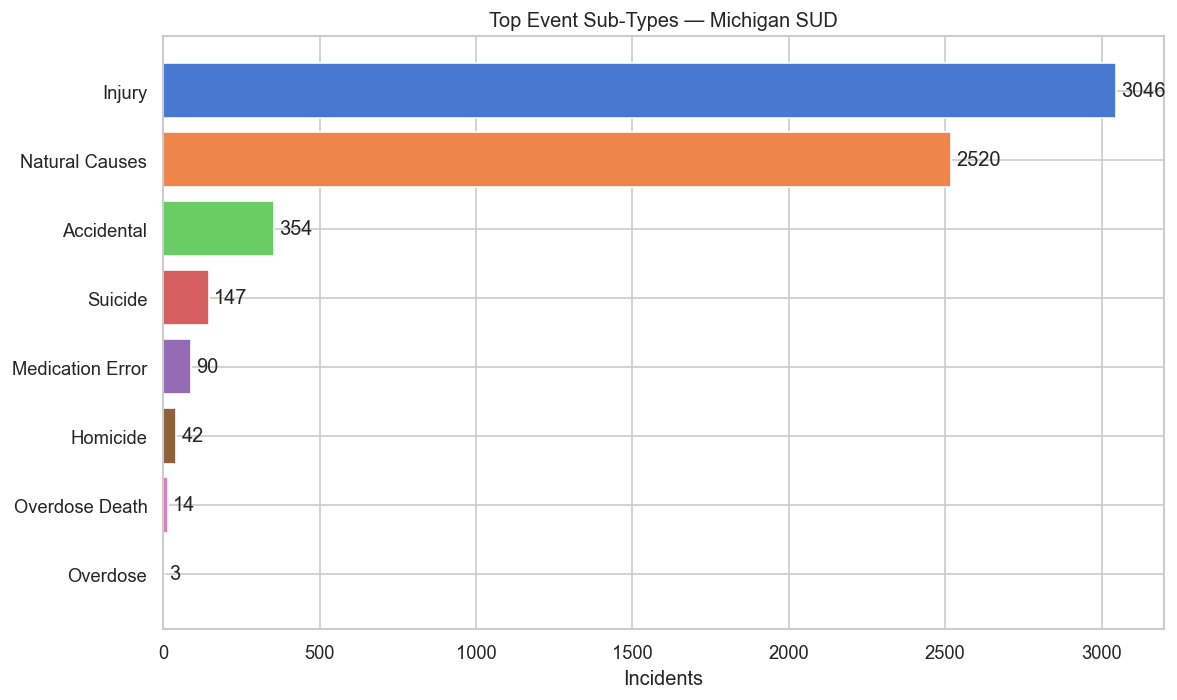

In [6]:
sub = mi['Event Sub-Type'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sub.index, sub.values, color=sns.color_palette('muted', len(sub)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Incidents')
ax.set_title('Top Event Sub-Types — Michigan SUD')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4 · SUD Sentinel Events vs. Other

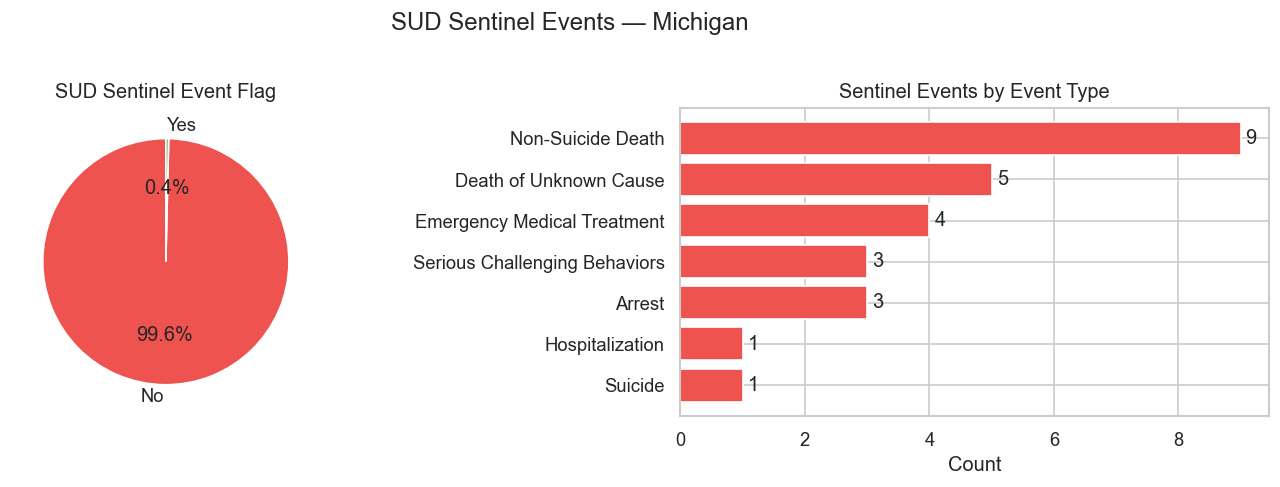

In [7]:
sentinel = mi['Is SUD Sentinel'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall pie
axes[0].pie(sentinel.values, labels=sentinel.index, autopct='%1.1f%%',
            colors=['#EF5350', '#66BB6A'], startangle=90)
axes[0].set_title('SUD Sentinel Event Flag')

# Sentinel events by event type
sentinel_by_type = mi[mi['Is this a SUD Sentinel Event?'] == 1]['Event Type'].value_counts()
axes[1].barh(sentinel_by_type.index, sentinel_by_type.values, color='#EF5350')
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_xlabel('Count')
axes[1].set_title('Sentinel Events by Event Type')
axes[1].invert_yaxis()

plt.suptitle('SUD Sentinel Events — Michigan', y=1.01)
plt.tight_layout()
plt.show()


## 5 · Event Type × Sub-Type Heatmap

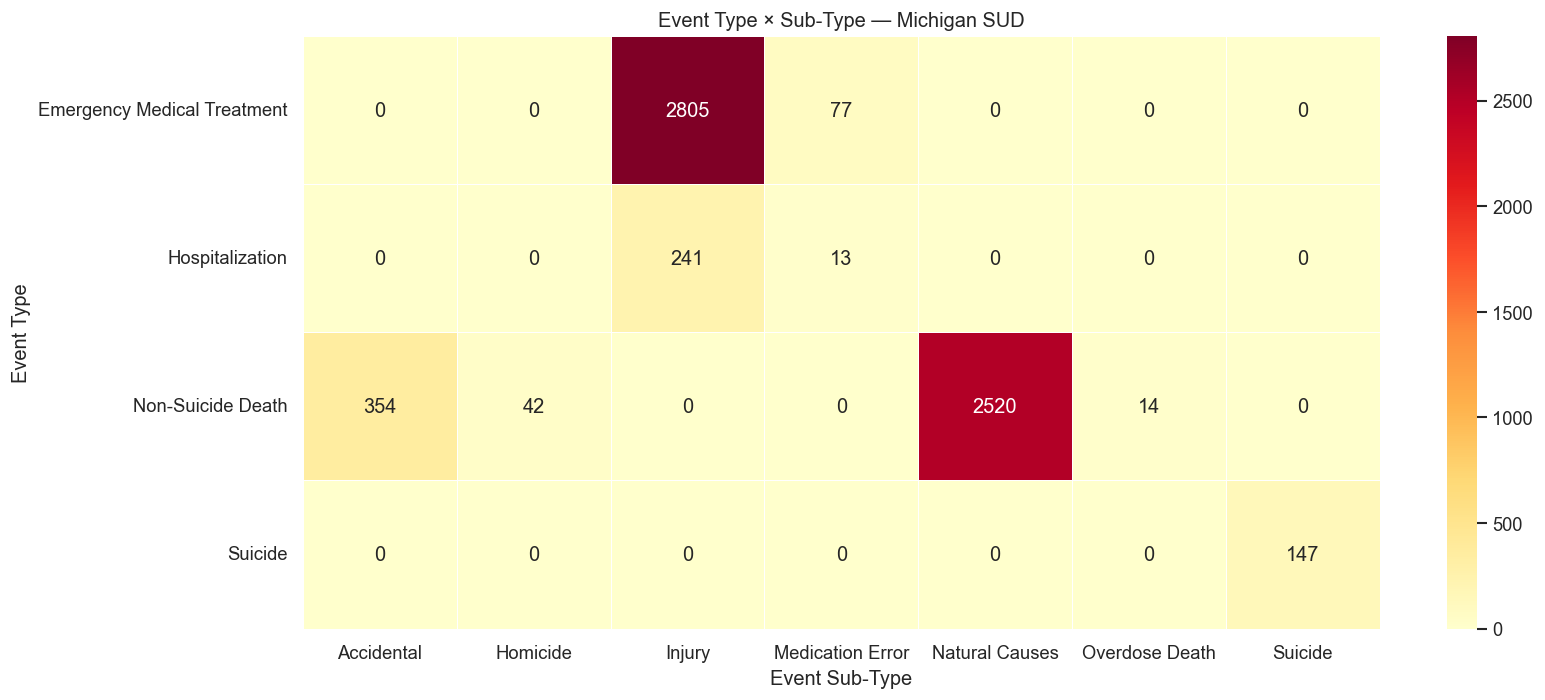

In [8]:
cross = mi.groupby(['Event Type', 'Event Sub-Type']).size().unstack(fill_value=0)
# Only keep sub-types with ≥5 records total for readability
cross = cross.loc[:, cross.sum() >= 5]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Event Type × Sub-Type — Michigan SUD')
plt.tight_layout()
plt.show()


## 6 · Clinician Review Lag

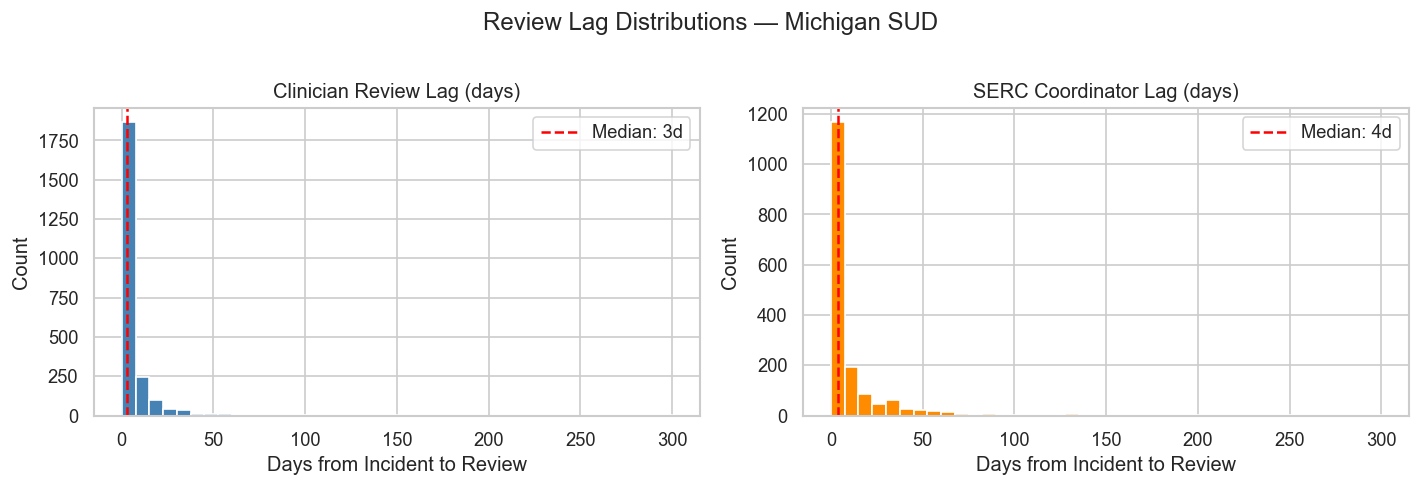

       clinician_lag      serc_lag
count    2361.000000   1670.000000
mean        8.039390     19.047305
std        22.091329    269.811248
min         0.000000      0.000000
25%         2.000000      2.000000
50%         3.000000      4.000000
75%         6.000000     10.000000
max       492.000000  10962.000000


In [9]:
mi['clinician_lag'] = (mi['Date IR Reviewed by Clinician'] - mi['Date of Incident']).dt.days
mi['serc_lag']      = (mi['Date IR Reviewed by SERC Coordinator'] - mi['Date of Incident']).dt.days

lag = mi[['clinician_lag', 'serc_lag']].dropna(how='all')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label, color in zip(axes,
                                  ['clinician_lag', 'serc_lag'],
                                  ['Clinician Review Lag (days)', 'SERC Coordinator Lag (days)'],
                                  ['steelblue', 'darkorange']):
    data = lag[col].dropna()
    data = data[(data >= 0) & (data <= 365)]  # remove outliers >1yr
    ax.hist(data, bins=40, color=color, edgecolor='white')
    ax.set_xlabel('Days from Incident to Review')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}d')
    ax.legend()

plt.suptitle('Review Lag Distributions — Michigan SUD', y=1.01)
plt.tight_layout()
plt.show()

print(lag.describe())


## 7 · Year-over-Year by Event Type

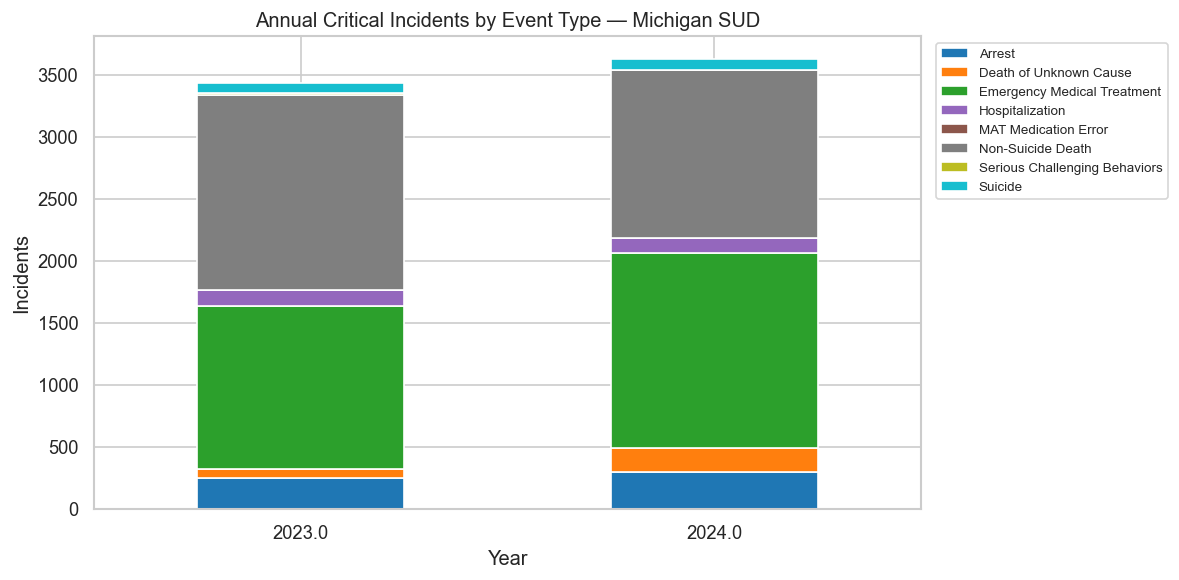

In [10]:
yoy = mi.groupby(['year', 'Event Type']).size().unstack(fill_value=0)

ax = yoy.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab10')
ax.set_title('Annual Critical Incidents by Event Type — Michigan SUD')
ax.set_xlabel('Year')
ax.set_ylabel('Incidents')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8 · Sub-Type Qualifier Breakdown

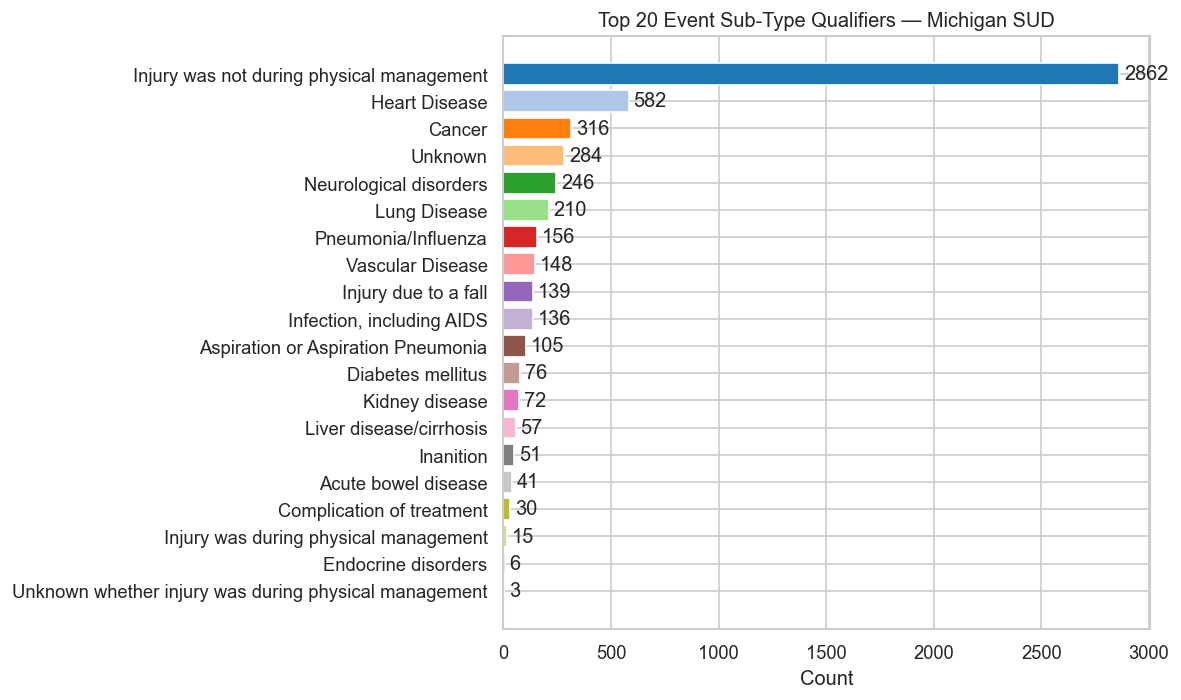

In [11]:
qual = mi['Event Sub-Type Qualifier'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(qual.index, qual.values, color=sns.color_palette('tab20', len(qual)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Count')
ax.set_title('Top 20 Event Sub-Type Qualifiers — Michigan SUD')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
